In [138]:
import numpy as np
import pandas as pd
import torch
import random
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch import optim

In [139]:
data = pd.read_csv(r"/home/rahul/Projects/deep-learning-projects/ann-tumor-classifier/data/breast_data.csv")

In [140]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [141]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [142]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [143]:
data = data.drop(columns=['Unnamed: 32', 'id'])

In [144]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [145]:
data.duplicated().sum()

np.int64(0)

In [146]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [147]:
class_counts = data['diagnosis'].value_counts()

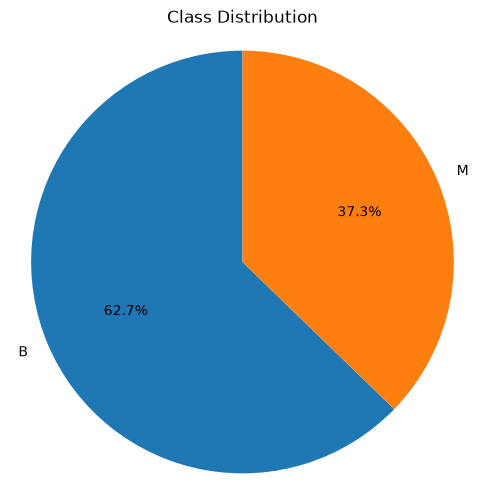

In [148]:
plt.figure(figsize=(6, 6))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
)
plt.title("Class Distribution")
plt.axis('equal')            
plt.show()

In [149]:
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})

In [150]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [151]:
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

In [152]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [154]:
scaler = StandardScaler()

In [155]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [156]:
X_train.dtype

dtype('float64')

In [157]:
X_train_tensor = torch.from_numpy(X_train.astype('float32'))
X_test_tensor = torch.from_numpy(X_test.astype('float32'))

In [158]:
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

In [159]:
#---------CustomDataset-------------#
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [160]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

In [161]:
#---------Train and test loaders----------------#
train_loaders = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loaders = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [162]:
#--------------Model architecture----------------#
class BreastCancerNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(num_features, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )
        
    def forward(self, x):
        return self.model(x)

In [163]:
epochs = 200
learning_rate = 0.001

In [164]:
model = BreastCancerNN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0
)

In [165]:
#---------------Training Loop-------------------#

for epoch in range(epochs):
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loaders:
        
        # forward pass
        outputs = model(batch_features)
        
        # loss calculation
        loss = criterion(outputs, batch_labels)
        
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # update grads
        optimizer.step()
        
        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loaders)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.6705282211303711
Epoch: 2 , Loss: 0.622209906578064
Epoch: 3 , Loss: 0.5459066867828369
Epoch: 4 , Loss: 0.43354257146517433
Epoch: 5 , Loss: 0.34437262018521625
Epoch: 6 , Loss: 0.2649022102355957
Epoch: 7 , Loss: 0.21302383691072463
Epoch: 8 , Loss: 0.16901908814907074
Epoch: 9 , Loss: 0.13513362805048626
Epoch: 10 , Loss: 0.1174673347423474
Epoch: 11 , Loss: 0.10418514646589756
Epoch: 12 , Loss: 0.09711990083257357
Epoch: 13 , Loss: 0.09385158071915309
Epoch: 14 , Loss: 0.0815620630979538
Epoch: 15 , Loss: 0.07756717267135779
Epoch: 16 , Loss: 0.07438641401628653
Epoch: 17 , Loss: 0.06677495539188386
Epoch: 18 , Loss: 0.06414926281819741
Epoch: 19 , Loss: 0.06539566355446974
Epoch: 20 , Loss: 0.06445228972782692
Epoch: 21 , Loss: 0.05764610152691603
Epoch: 22 , Loss: 0.054416898358613255
Epoch: 23 , Loss: 0.05339681648959716
Epoch: 24 , Loss: 0.05097817980373899
Epoch: 25 , Loss: 0.052816195599734786
Epoch: 26 , Loss: 0.04916161751995484
Epoch: 27 , Loss: 0.048132

In [166]:
model.eval()

BreastCancerNN(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)

In [167]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in train_loaders:

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, dim=1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total

print(f"Train Accuracy: {accuracy:.2f}%")

Train Accuracy: 100.00%


In [168]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loaders:

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, dim=1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.25%


In [169]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    y_pred = torch.argmax(outputs, dim=1)

In [170]:
y_true = y_test_tensor.cpu().numpy()
y_pred = y_pred.cpu().numpy()

In [171]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

Accuracy : 0.9824561403508771
Precision: 0.9761904761904762
Recall   : 0.9761904761904762
F1 Score : 0.9761904761904762


In [172]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_true, y_pred))

[[71  1]
 [ 1 41]]
